In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("plots.mplstyle")

# Pulse sequences

## CW ODMR

CH1 drives the AOM continuously (always on). CH2 drives the microwave, chopped on/off at 50% duty cycle -- also the lock-in amplifier's reference.

In [2]:
def square_wave(t, period, duty=0.5):
    """1 where high, 0 where low, for a duty-cycle square wave of the given period."""
    return (np.mod(t, period) < duty * period).astype(float)


def plot_channel(ax, t, signal, y_offset, label, color):
    ax.step(t, signal + y_offset, where="post", color=color, linewidth=2)
    ax.text(
        t[0] - 0.03 * (t[-1] - t[0]),
        y_offset + 0.5,
        label,
        ha="right",
        va="center",
        fontsize=10,
        color=color,
    )


def label_states(ax, t, signal, y_offset, color):
    """Label each constant on/off segment of signal at its midpoint, centered
    vertically between the high and low levels."""
    change_idx = np.where(np.diff(signal) != 0)[0] + 1
    seg_starts = np.concatenate(([0], change_idx))
    seg_ends = np.concatenate((change_idx, [len(t) - 1]))
    for start, end in zip(seg_starts, seg_ends):
        mid_t = (t[start] + t[end]) / 2
        state = "on" if signal[start] > 0.5 else "off"
        ax.text(
            mid_t,
            y_offset + 0.5,
            state,
            ha="center",
            va="center",
            fontsize=14,
            color=color,
        )

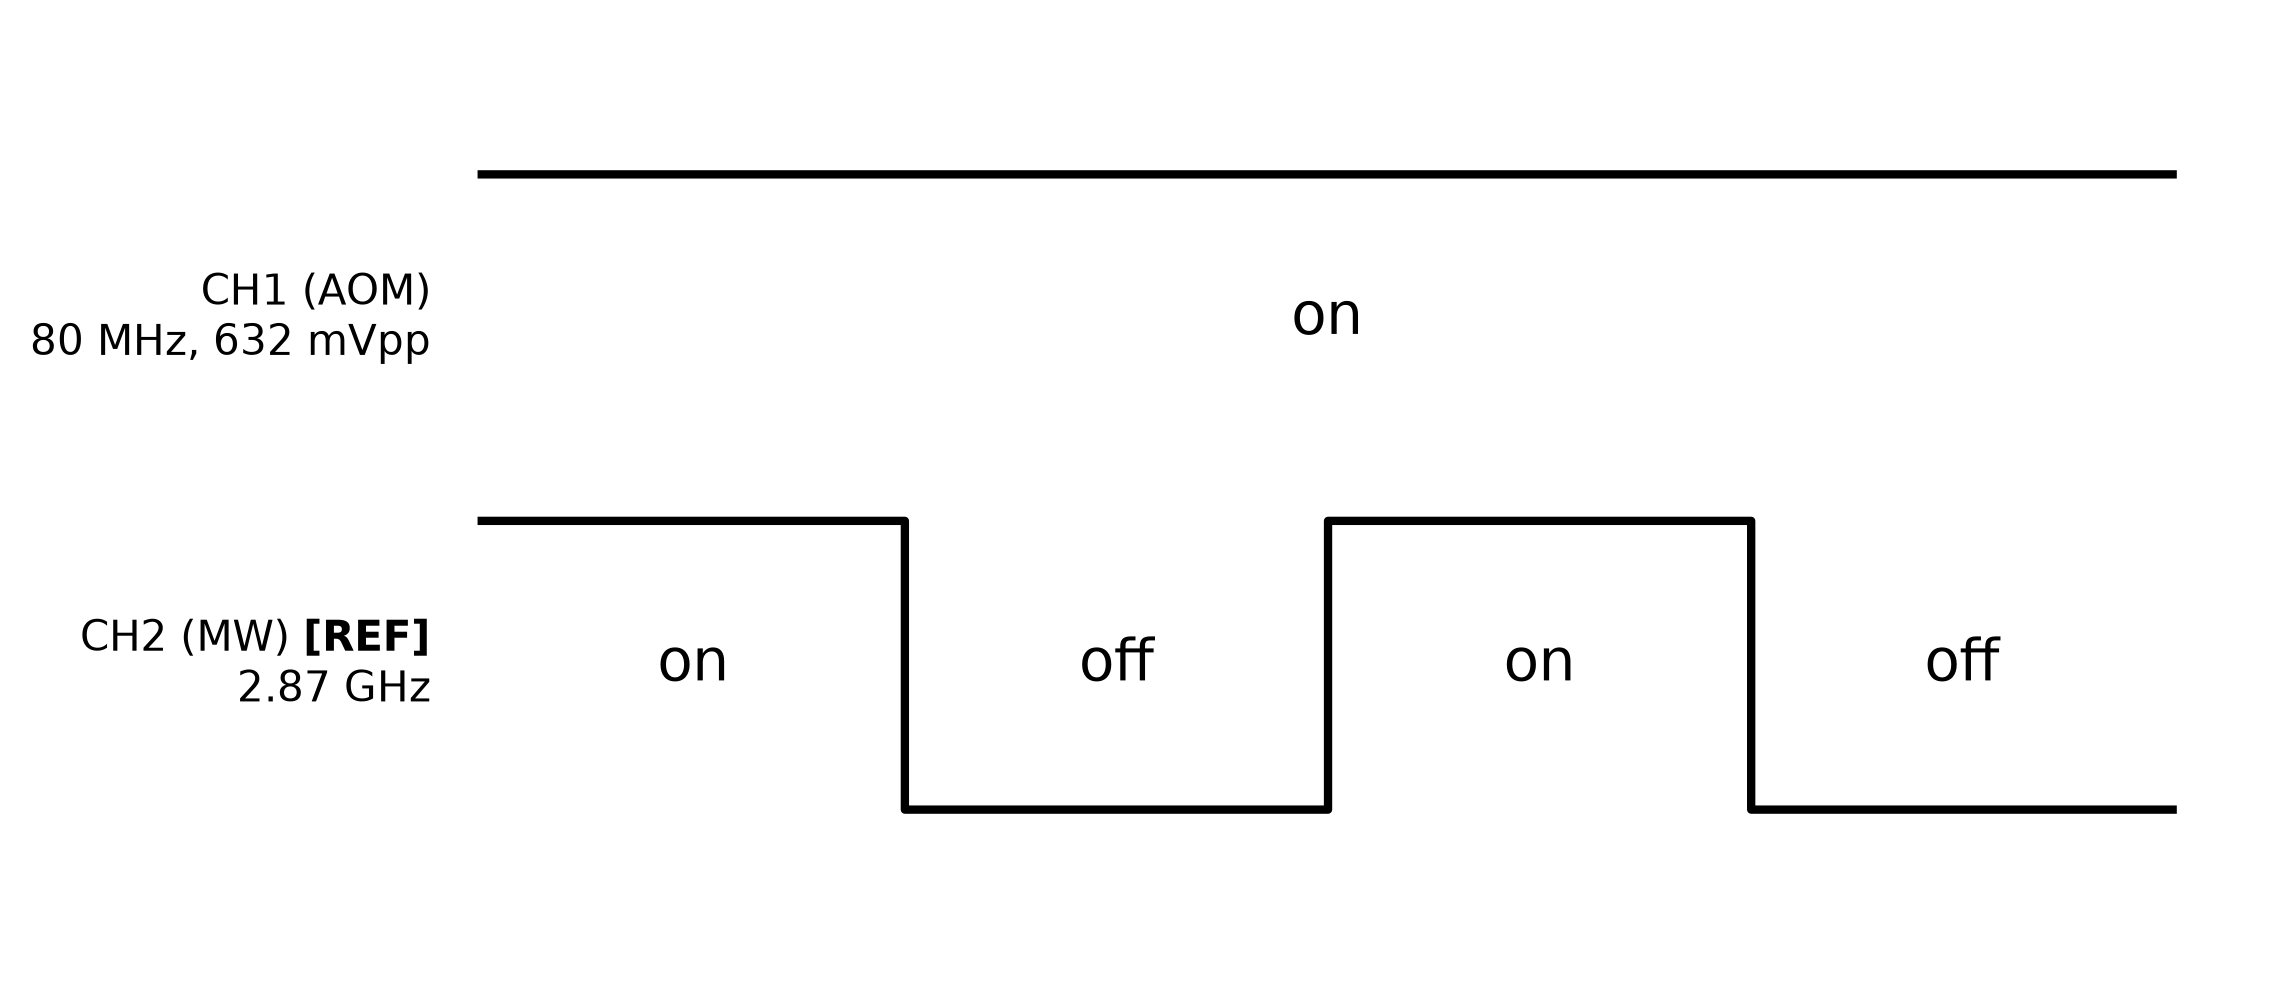

In [3]:
t = np.linspace(0, 2, 1000, endpoint=False)
ch1_signal = np.ones_like(t)
ch2_signal = square_wave(t, period=1.0, duty=0.5)

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
plot_channel(ax, t, ch1_signal, y_offset=1.2, label="CH1 (AOM)\n80 MHz, 632 mVpp", color="black")
plot_channel(
    ax,
    t,
    ch2_signal,
    y_offset=0,
    label="CH2 (MW) $\\mathbf{[REF]}$\n2.87 GHz",
    color="black",
)
label_states(ax, t, ch1_signal, y_offset=1.2, color="black")
label_states(ax, t, ch2_signal, y_offset=0, color="black")
ax.set_ylim(-0.5, 2.7)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

## Pulsed ODMR

SYNC (the lock-in reference) is chopped at 50% duty cycle -- one duty cycle shown. While SYNC is high, CH1 (AOM) cycles on for 5 us, dark for 1 us, stays dark while CH2 (MW) turns on for `tau_mw`, then dark for another 1 us; this repeats for N repetitions (drawn once). While SYNC is low, CH1 keeps the same cycle, but CH2 stays off the whole time.

In [4]:
def plot_segments(ax, segments, y_offset, color, x0=0, linewidth=2):
    """segments: list of (duration, level in {0, 1}). Draws a step waveform
    starting at x0 and returns the end x position."""
    xs = [x0]
    ys = [segments[0][1]]
    x = x0
    for duration, level in segments:
        xs.append(x)
        ys.append(level)
        x += duration
        xs.append(x)
        ys.append(level)
    ax.plot(xs, np.array(ys) + y_offset, color=color, linewidth=linewidth)
    return x


def label_durations(ax, segments, labels, y, x0=0, fontsize=12, color="black"):
    """Label each segment's duration centered above/below its own span, at a
    shared height y (independent of any channel's own on/off level)."""
    x = x0
    for (duration, _), label in zip(segments, labels):
        if label:
            ax.text(
                x + duration / 2, y, label, ha="center", va="center",
                fontsize=fontsize, color=color, zorder=3,
            )
        x += duration


def draw_repeat_bracket(ax, x_start, x_end, y, text, fontsize=12, tick=0.1):
    ax.plot(
        [x_start, x_start, x_end, x_end],
        [y - tick, y, y, y - tick],
        color="black",
        linewidth=1,
    )
    ax.text((x_start + x_end) / 2, y + 0.1, text, ha="center", va="bottom", fontsize=fontsize)


def draw_ellipsis(ax, x, y, fontsize=18):
    ax.text(x, y, "⋯", ha="center", va="center", fontsize=fontsize)


def draw_boundary_lines(ax, segments, y_bottom, y_top, x0=0, color="gray"):
    """Dotted vertical guide lines at every segment boundary (including the
    ends), spanning from y_bottom to y_top, to show CH1/CH2 are synced."""
    x = x0
    boundaries = [x0]
    for duration, _ in segments:
        x += duration
        boundaries.append(x)
    for xb in boundaries:
        ax.plot([xb, xb], [y_bottom, y_top], linestyle=":", color=color, linewidth=1, zorder=1)

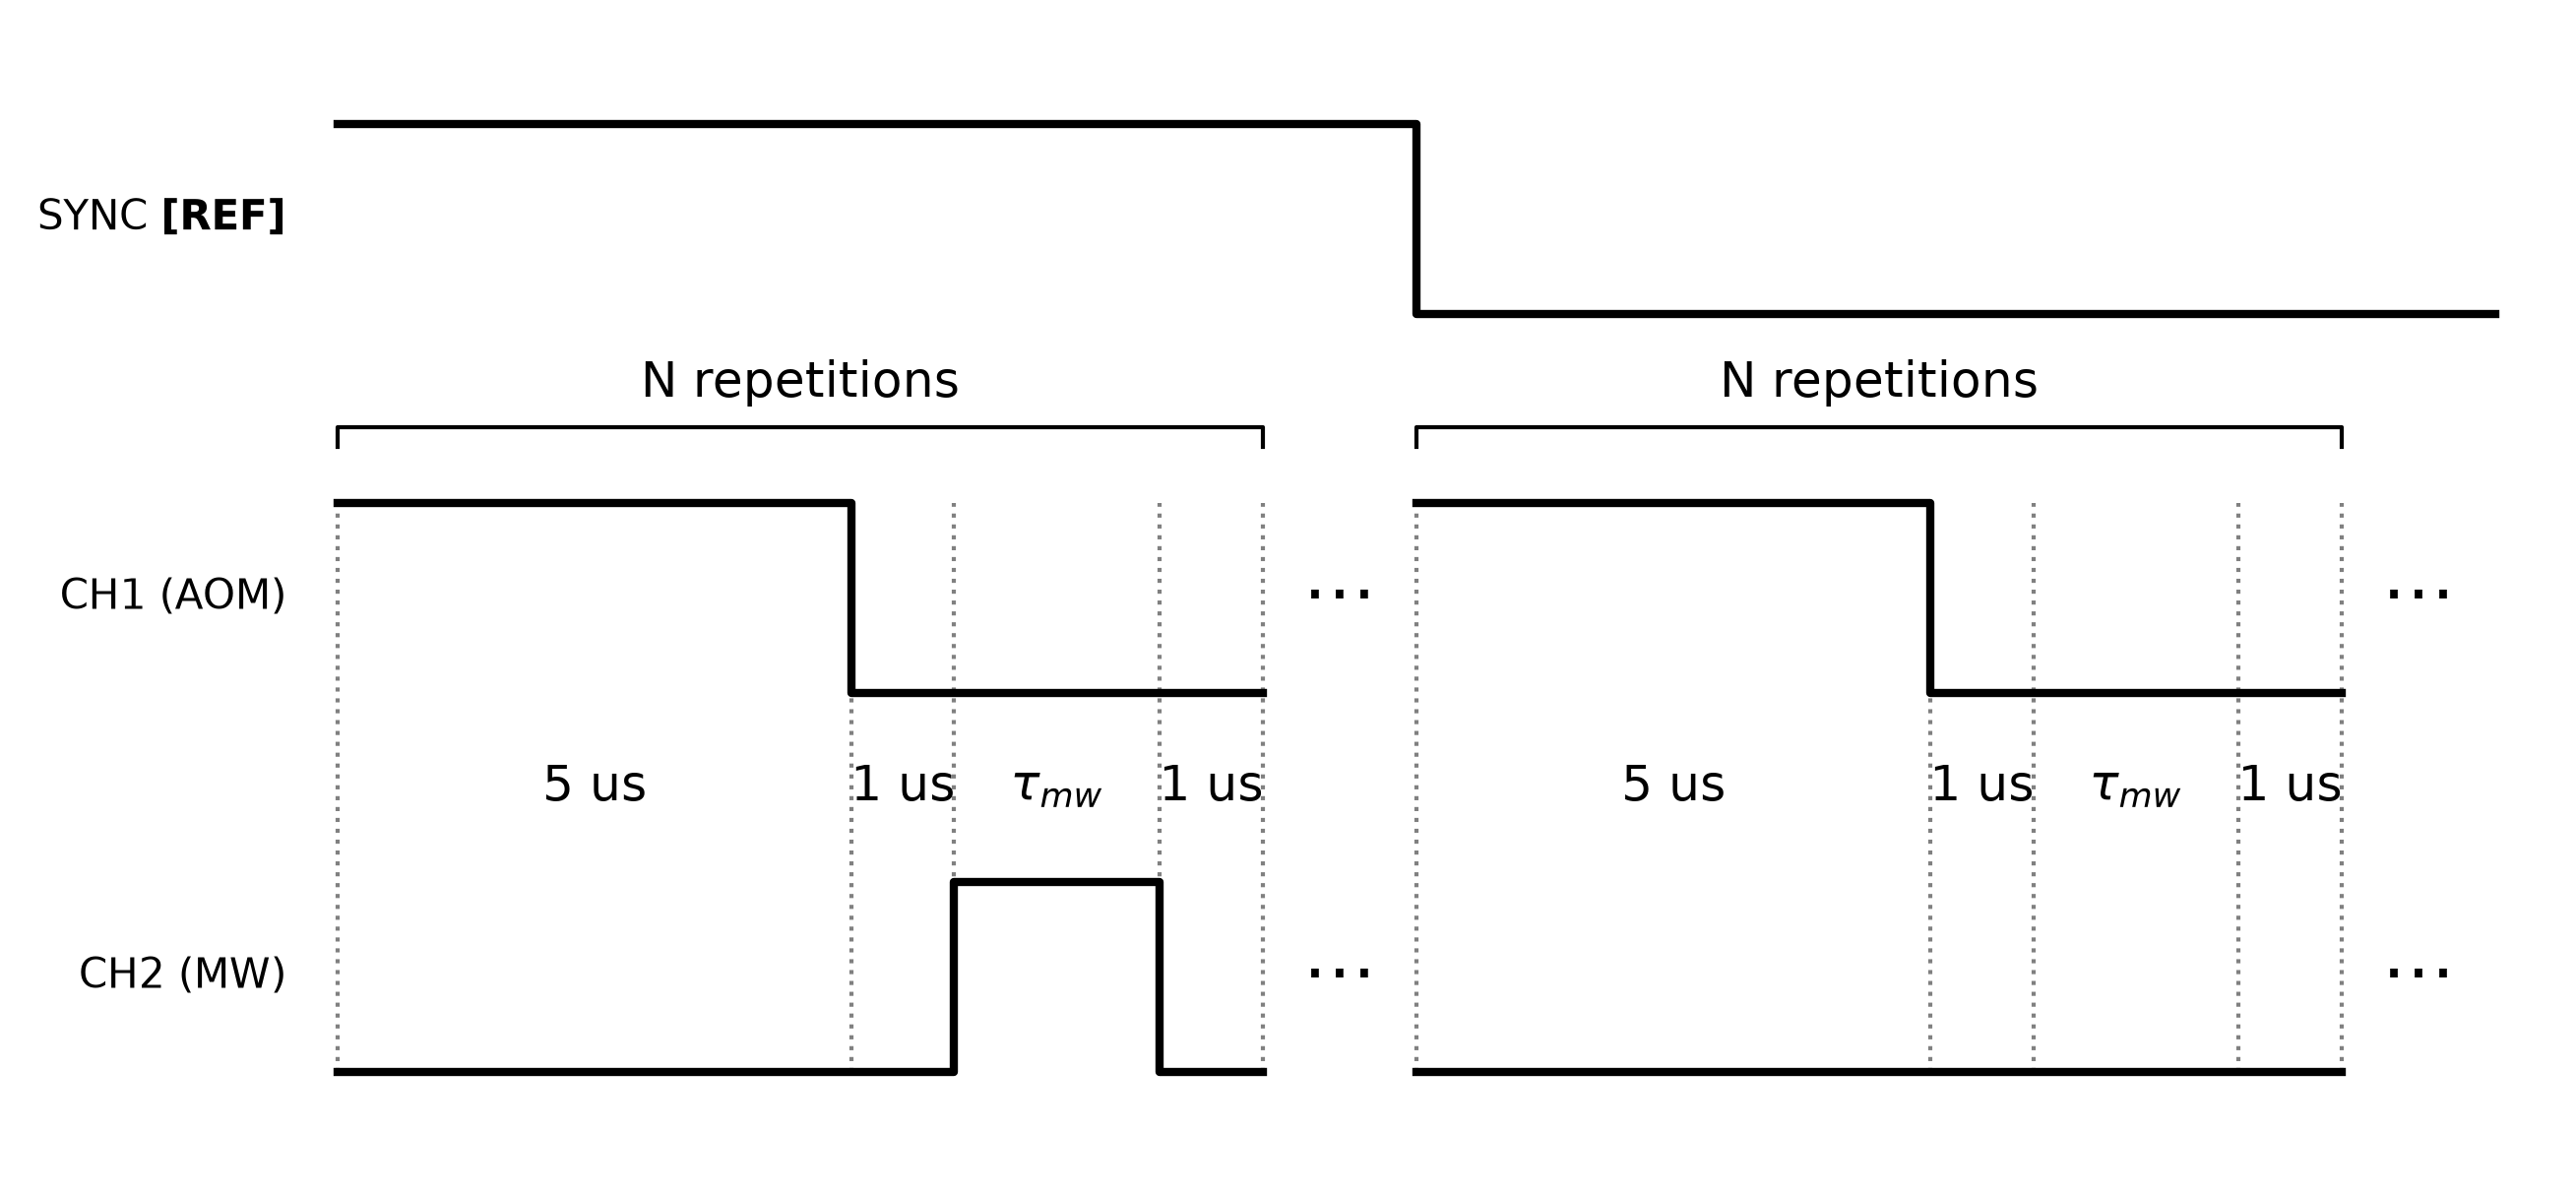

In [5]:
T_ON = 5.0  # us, CH1 laser on
T_DARK = 1.0  # us, dark gaps around the MW pulse
T_TAU = 2.0  # schematic width standing in for tau_mw (not to scale)
ELLIPSIS_GAP = 1.5

repeat_ch1 = [(T_ON, 1), (T_DARK, 0), (T_TAU, 0), (T_DARK, 0)]
repeat_ch2_mw_on = [(T_ON, 0), (T_DARK, 0), (T_TAU, 1), (T_DARK, 0)]
repeat_ch2_mw_off = [(T_ON, 0), (T_DARK, 0), (T_TAU, 0), (T_DARK, 0)]
repeat_labels = ["5 us", "1 us", r"$\tau_{mw}$", "1 us"]

y_sync, y_ch1, y_ch2 = 4, 2, 0
y_time_labels = 1.5
y_bracket = 3.4

fig, ax = plt.subplots(figsize=(11, 5), dpi=300)

# --- SYNC high phase: one repeat unit (MW on), then "..." for N repetitions ---
x0 = 0
end_ch1 = plot_segments(ax, repeat_ch1, y_ch1, "black", x0=x0)
plot_segments(ax, repeat_ch2_mw_on, y_ch2, "black", x0=x0)
label_durations(ax, repeat_ch1, repeat_labels, y_time_labels, x0=x0)
draw_boundary_lines(ax, repeat_ch1, y_ch2, y_ch1 + 1, x0=x0)
draw_repeat_bracket(ax, x0, end_ch1, y_bracket, "N repetitions")

x1 = end_ch1
draw_ellipsis(ax, x1 + ELLIPSIS_GAP / 2, y_ch1 + 0.5)
draw_ellipsis(ax, x1 + ELLIPSIS_GAP / 2, y_ch2 + 0.5)
sync_high_end = x1 + ELLIPSIS_GAP

# --- SYNC low phase: same CH1 cycle, CH2 off the whole time ---
end_ch1b = plot_segments(ax, repeat_ch1, y_ch1, "black", x0=sync_high_end)
plot_segments(ax, repeat_ch2_mw_off, y_ch2, "black", x0=sync_high_end)
label_durations(ax, repeat_ch1, repeat_labels, y_time_labels, x0=sync_high_end)
draw_boundary_lines(ax, repeat_ch1, y_ch2, y_ch1 + 1, x0=sync_high_end)
draw_repeat_bracket(ax, sync_high_end, end_ch1b, y_bracket, "N repetitions")

x3 = end_ch1b
draw_ellipsis(ax, x3 + ELLIPSIS_GAP / 2, y_ch1 + 0.5)
draw_ellipsis(ax, x3 + ELLIPSIS_GAP / 2, y_ch2 + 0.5)
sync_low_end = x3 + ELLIPSIS_GAP

# --- SYNC channel: one duty cycle, high for the MW-on phase, low for the MW-off phase ---
sync_segments = [(sync_high_end - x0, 1), (sync_low_end - sync_high_end, 0)]
plot_segments(ax, sync_segments, y_sync, "black", x0=x0)

for y, text in [
    (y_sync, "SYNC $\\mathbf{[REF]}$"),
    (y_ch1, "CH1 (AOM)"),
    (y_ch2, "CH2 (MW)"),
]:
    ax.text(x0 - 0.5, y + 0.5, text, ha="right", va="center", fontsize=10)

ax.set_xlim(x0 - 3, sync_low_end + 0.5)
ax.set_ylim(-0.5, y_sync + 1.5)
ax.axis("off")
plt.show()

## All-optical T1 readout

CH1 (AOM) polarizes for 10 us, waits dark for `dark_time`, then reads out for 300 ns. SYNC only pulses during the readout window, triggering the scope.

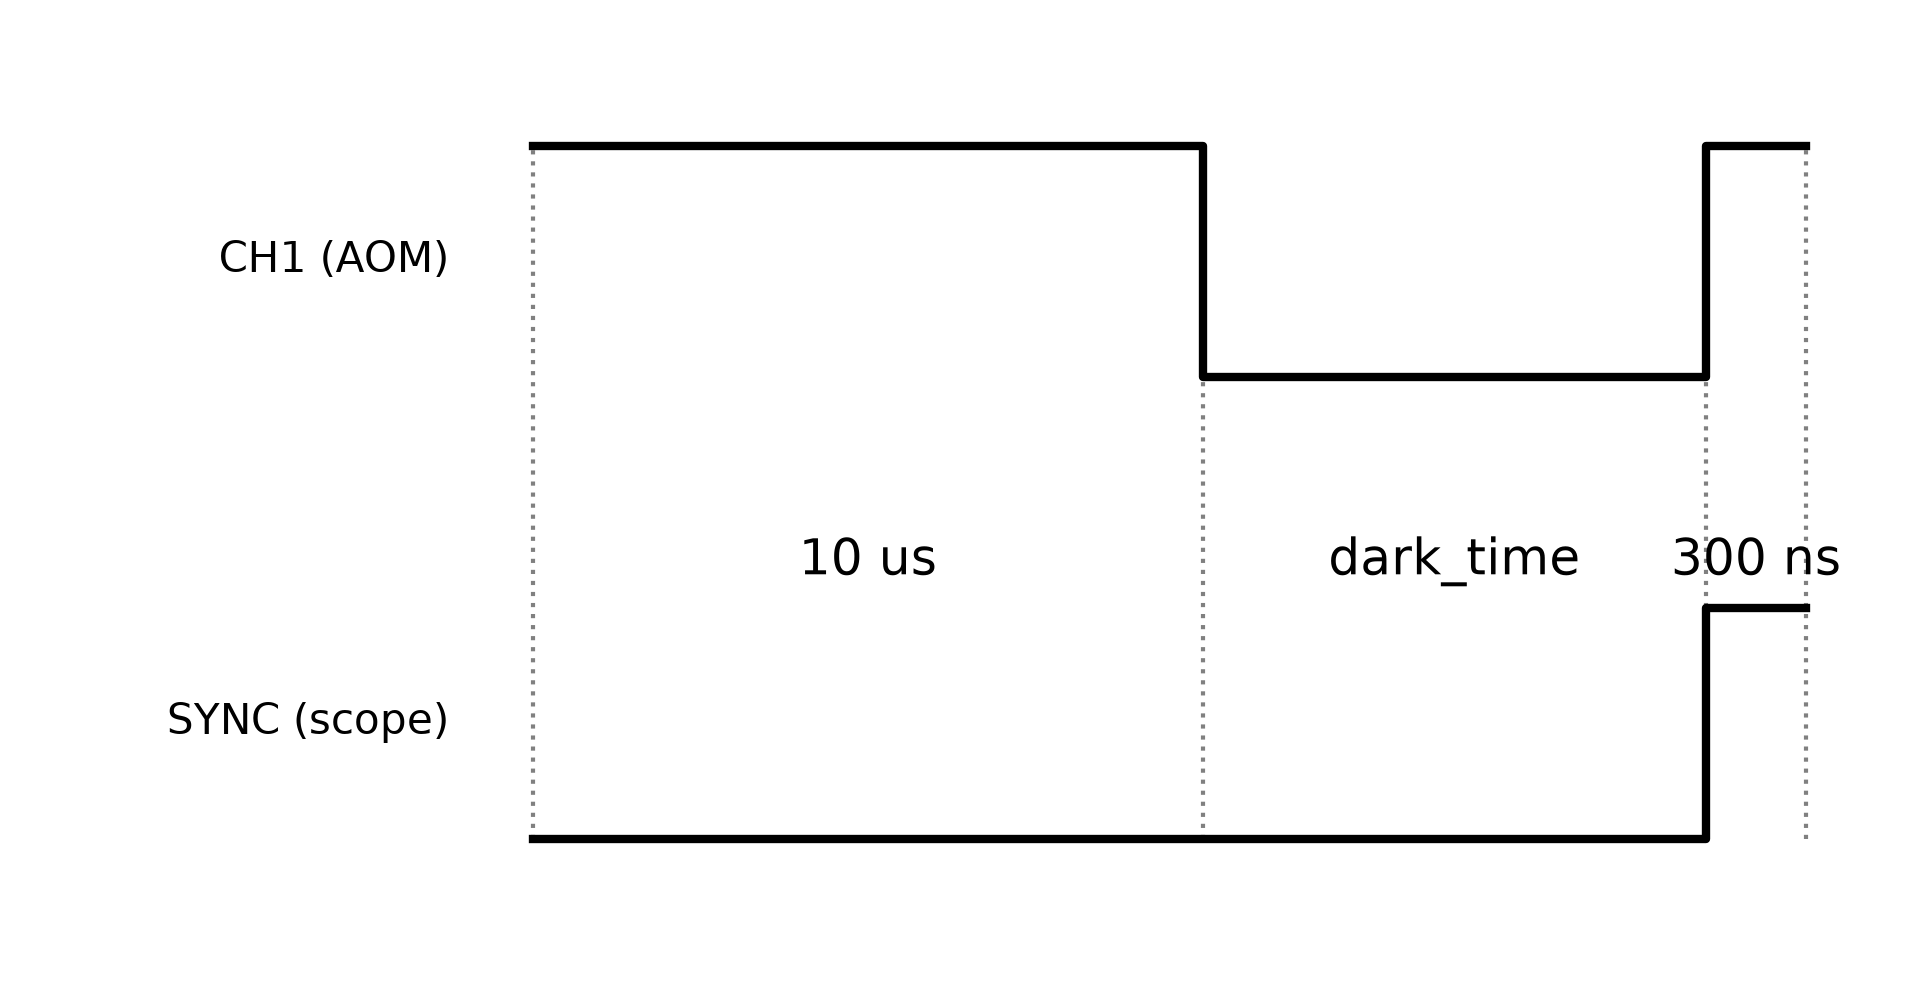

In [6]:
T_POL = 4.0  # schematic width for the 10 us polarize pulse
T_DARK_T1 = 3.0  # schematic width standing in for dark_time (not to scale)
T_RO = 0.6  # schematic width for the 300 ns readout pulse

t1_ch1 = [(T_POL, 1), (T_DARK_T1, 0), (T_RO, 1)]
t1_sync = [(T_POL, 0), (T_DARK_T1, 0), (T_RO, 1)]
t1_labels = ["10 us", "dark_time", "300 ns"]

y_ch1_t1, y_sync_t1 = 2, 0
y_time_labels_t1 = 1.2

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

x0 = 0
plot_segments(ax, t1_ch1, y_ch1_t1, "black", x0=x0)
plot_segments(ax, t1_sync, y_sync_t1, "black", x0=x0)
label_durations(ax, t1_ch1, t1_labels, y_time_labels_t1, x0=x0)
draw_boundary_lines(ax, t1_ch1, y_sync_t1, y_ch1_t1 + 1, x0=x0)

for y, text in [(y_ch1_t1, "CH1 (AOM)"), (y_sync_t1, "SYNC (scope)")]:
    ax.text(x0 - 0.5, y + 0.5, text, ha="right", va="center", fontsize=10)

ax.set_xlim(x0 - 3, T_POL + T_DARK_T1 + T_RO + 0.5)
ax.set_ylim(-0.5, y_ch1_t1 + 1.5)
ax.axis("off")
plt.show()